In [2]:
#OOB Forest
#Create datasets

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples = 50000,
    n_features = 20,
    n_informative = 10,
    n_redundant = 5,
    random_state = 42
)

#Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [4]:
#Train
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators = 100,
    oob_score = True,
    random_state = 42,
    n_jobs = -1
)
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
#OOB score
print("OOB Score: ", forest.oob_score)

OOB Score:  True


In [6]:
#Compare against the test set
test_accuracy = forest.score(
    X_test,
    y_test
)
print("OOB: ", forest.oob_score_)
print("Test: ", test_accuracy)

OOB:  0.95085
Test:  0.956


In [9]:
#Cross validation comparision
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    forest,
    X_train,
    y_train,
    cv = 5,
    scoring = "accuracy"
)

print("CV scores: ", cv_scores)
print("CV mean: ", cv_scores.mean())

CV scores:  [0.9505   0.954875 0.95175  0.95     0.9515  ]
CV mean:  0.951725


In [10]:
#Feature importance
#inspect what forest learned

import pandas as pd

importance = pd.Series(
    forest.feature_importances_,
    index = [
        f"Feature_{i}"
        for i in range(X.shape[1])
    ]
)

importance = importance.sort_values(ascending = False)
print(importance)

Feature_9     0.157198
Feature_15    0.118736
Feature_13    0.071589
Feature_10    0.067735
Feature_1     0.067726
Feature_3     0.065499
Feature_18    0.064023
Feature_8     0.061366
Feature_2     0.047748
Feature_0     0.046012
Feature_14    0.044160
Feature_17    0.043600
Feature_6     0.041229
Feature_12    0.030078
Feature_11    0.025177
Feature_19    0.009886
Feature_7     0.009826
Feature_4     0.009497
Feature_5     0.009469
Feature_16    0.009446
dtype: float64


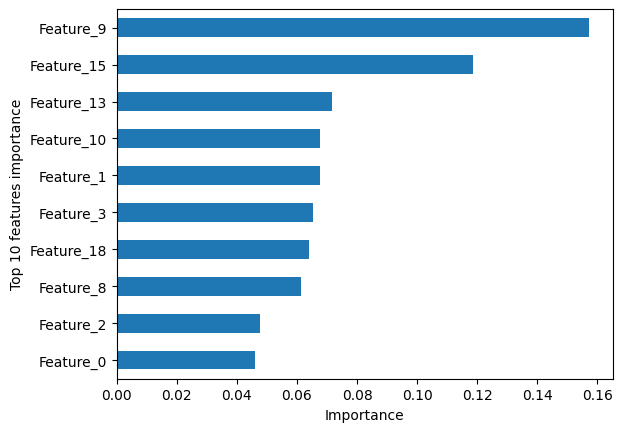

In [12]:
#Plot
import matplotlib.pyplot as plt

importance.head(10).sort_values().plot(kind = "barh")

plt.xlabel("Importance")
plt.ylabel("Top 10 features importance")
plt.show()